In [3]:
from misc import *
import constant

In [4]:
# upto 5 long track candidates isMuon
LTRACK5_FILE_PATH = "/dice/projects/LHCb/PbPb_MSCi/isMuon_Tr1_5_B2JpsiK_PbPb/LeadLead_B2JpsiKTuple_all.root"
DEFAULT_TREE_NAME = "B2JpsiKTuple/DecayTree"

df = load_root(LTRACK5_FILE_PATH, DEFAULT_TREE_NAME)
df = df[df["Kplus_isMuon"] == False]
df = df[(constant.JPSI_MASS-65 <= df["J_psi_1S_M"]) & (df["J_psi_1S_M"] <= constant.JPSI_MASS+65)]

Histogram saved to figures/Report/chi2.svg


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='Mass [$\\mathrm{MeV}/c^2$]', ylabel='Candidates / (5 $\\mathrm{MeV}/c^2$)'>)

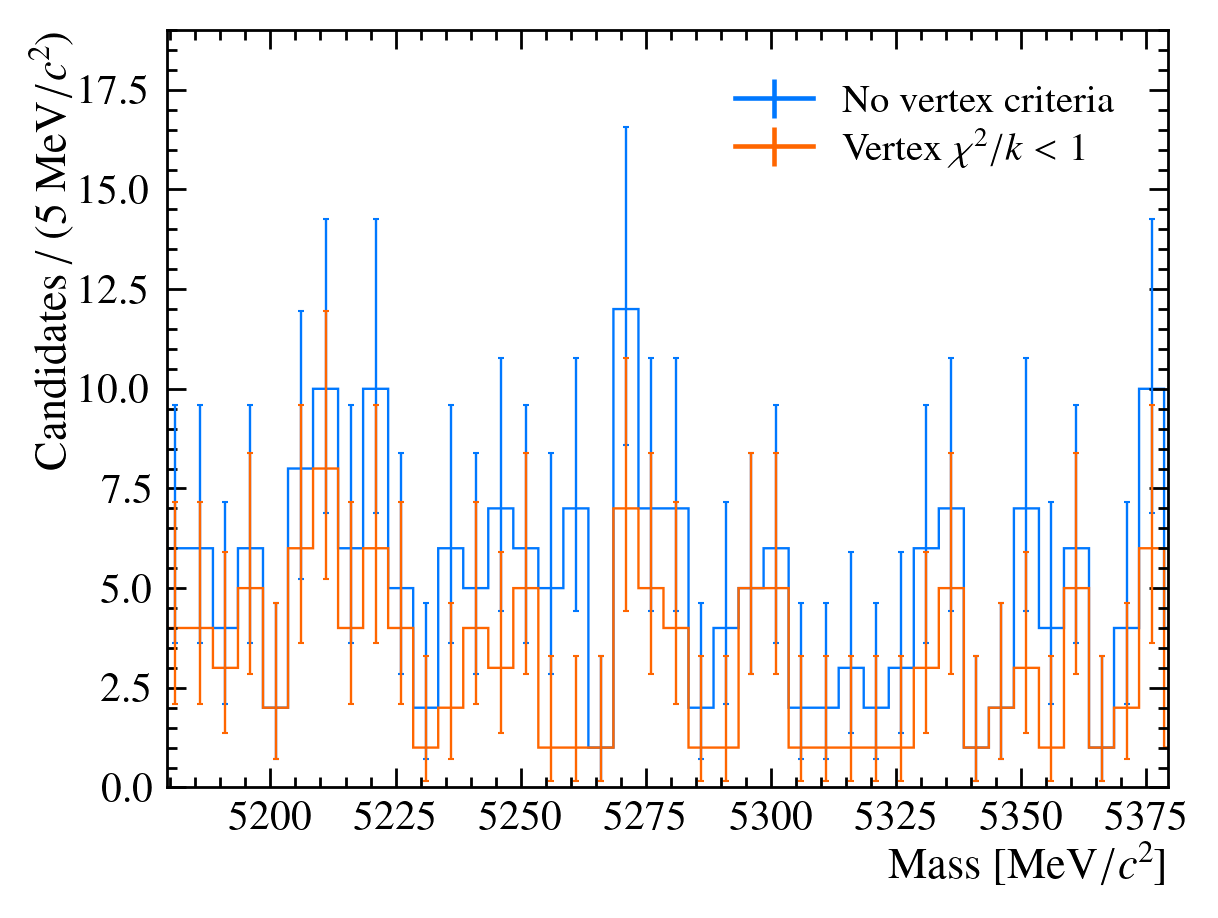

In [5]:
histogram_fig(
    [
        first := HistogramPlot(df["Bplus_M"], "No vertex criteria", bins=5, error=True, lw=1.7),
        HistogramPlot(
            df[df["Bplus_ENDVERTEX_CHI2"]/df["Bplus_ENDVERTEX_NDOF"] < 1]["Bplus_M"],
            r"Vertex $\chi^2/k < 1$",
            bins=first.bin_edges,
            error=True,
            lw=1.7,
        ),
    ],
    "figures/Report/chi2.svg",
    xlabel="Mass",
    unit_tex=r"\mathrm{MeV}/c^2",
    preset="Bplus Mass",
    ylim=[0,19]
)

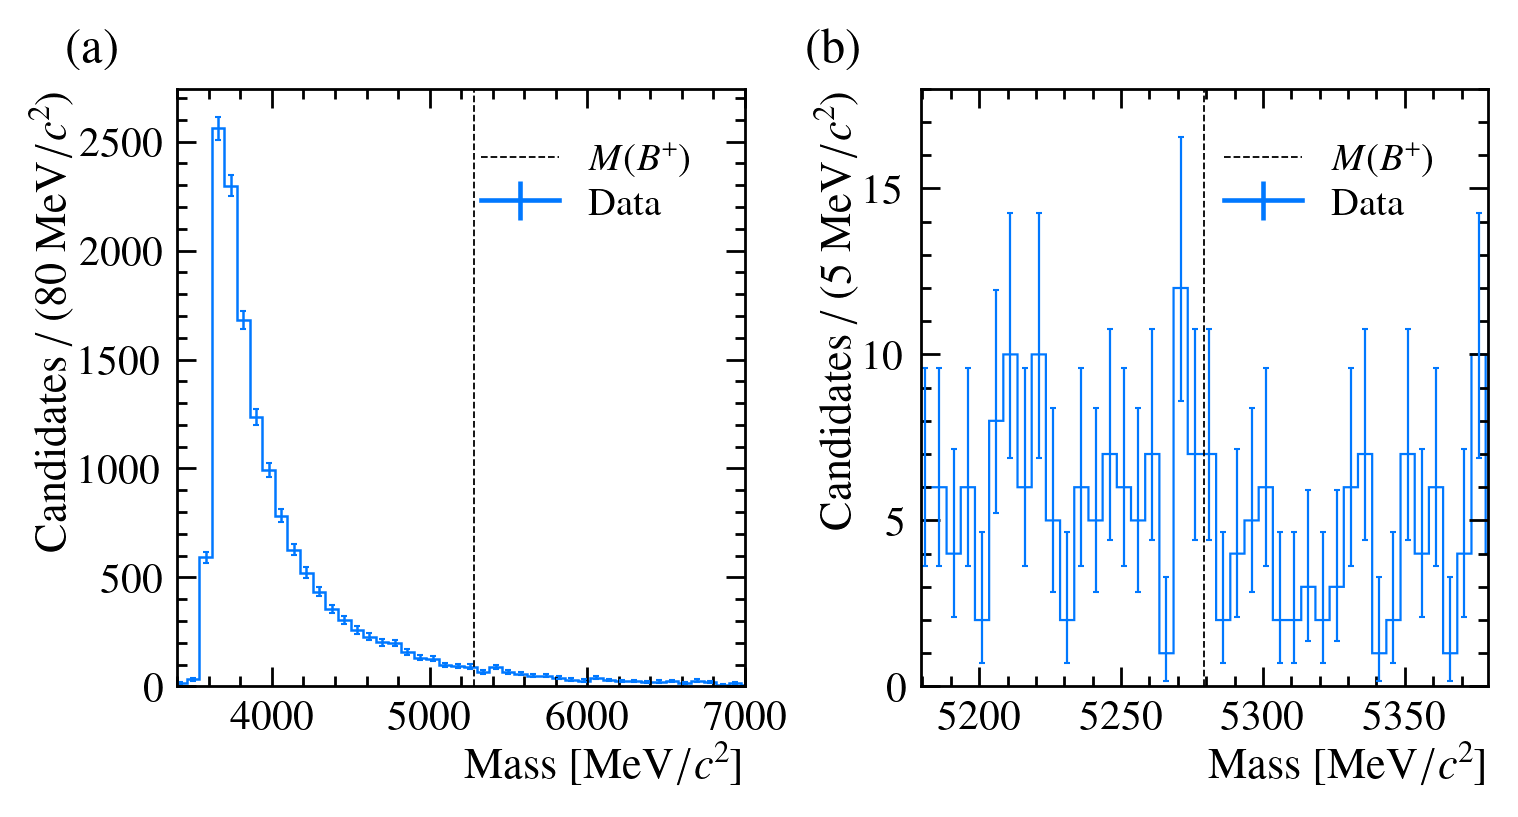

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5*3, 4*2))

histogram_ax(
    [HistogramPlot(df["Bplus_M"], r"Data", True, 80, lw=1.8)],
    ax=ax1,
    xlabel="Mass",
    unit_tex=r"\mathrm{MeV}/c^2",
    xlim=[3400, 7000]
)

ax1.axvline(constant.BPLUS_MASS, color="k", ls="--", lw=1.3, label=r"$M(B^+)$")
ax1.legend()


histogram_ax(
    [HistogramPlot(df["Bplus_M"], r"Data", True, 5, lw=1.6)],
    ax=ax2,
    xlabel="Mass",
    unit_tex=r"\mathrm{MeV}/c^2",
    xlim=[constant.BPLUS_MASS - 100, constant.BPLUS_MASS + 100],
    ylim=[0,18]
)

ax2.axvline(constant.BPLUS_MASS, color="k", ls="--", lw=1.3, label=r"$M(B^+)$")
ax2.legend()

ax1.text(-0.1, 1.1, '(a)', transform=ax1.transAxes, fontsize=35, fontweight='bold', va='top', ha='right')
ax2.text(-0.1, 1.1, '(b)', transform=ax2.transAxes, fontsize=35, fontweight='bold', va='top', ha='right')


fig.savefig("figures/Report/Bplus_mass.svg")

Histogram not saved to file


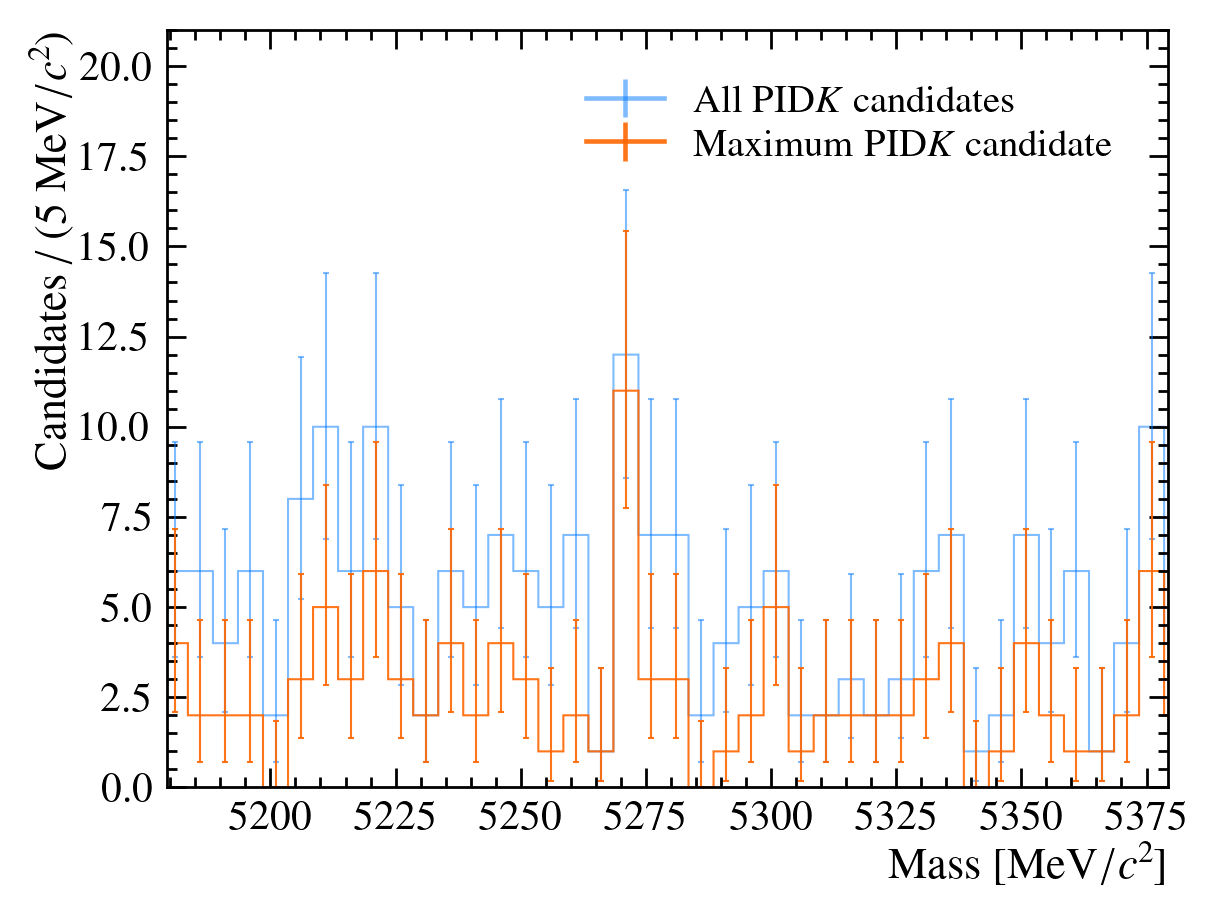

In [8]:
best_pidk_df, _ = filter_duplicates_by_performance(df, "Kplus_PIDK", "max")

fig, ax = histogram_fig(
    [
        first := HistogramPlot(
            df["Bplus_M"],
            r"All PID$K$ candidates",
            bins=5,
            error=True,
            alpha=0.5,
            linewidth=1.5,
        ),
        HistogramPlot(
            best_pidk_df["Bplus_M"],
            r"Maximum PID$K$ candidate",
            bins=first.bin_edges,
            error=True,
            alpha=0.9,
            linewidth=1.5,
        ),
    ],
    # "figures/week14/duplicates_removed_pidk_Bmass.png",
    False,
    preset="Bplus Mass",
    ylim=[0, 21],
)

fig.savefig("figures/Report/bestpidk.svg")

Histogram not saved to file


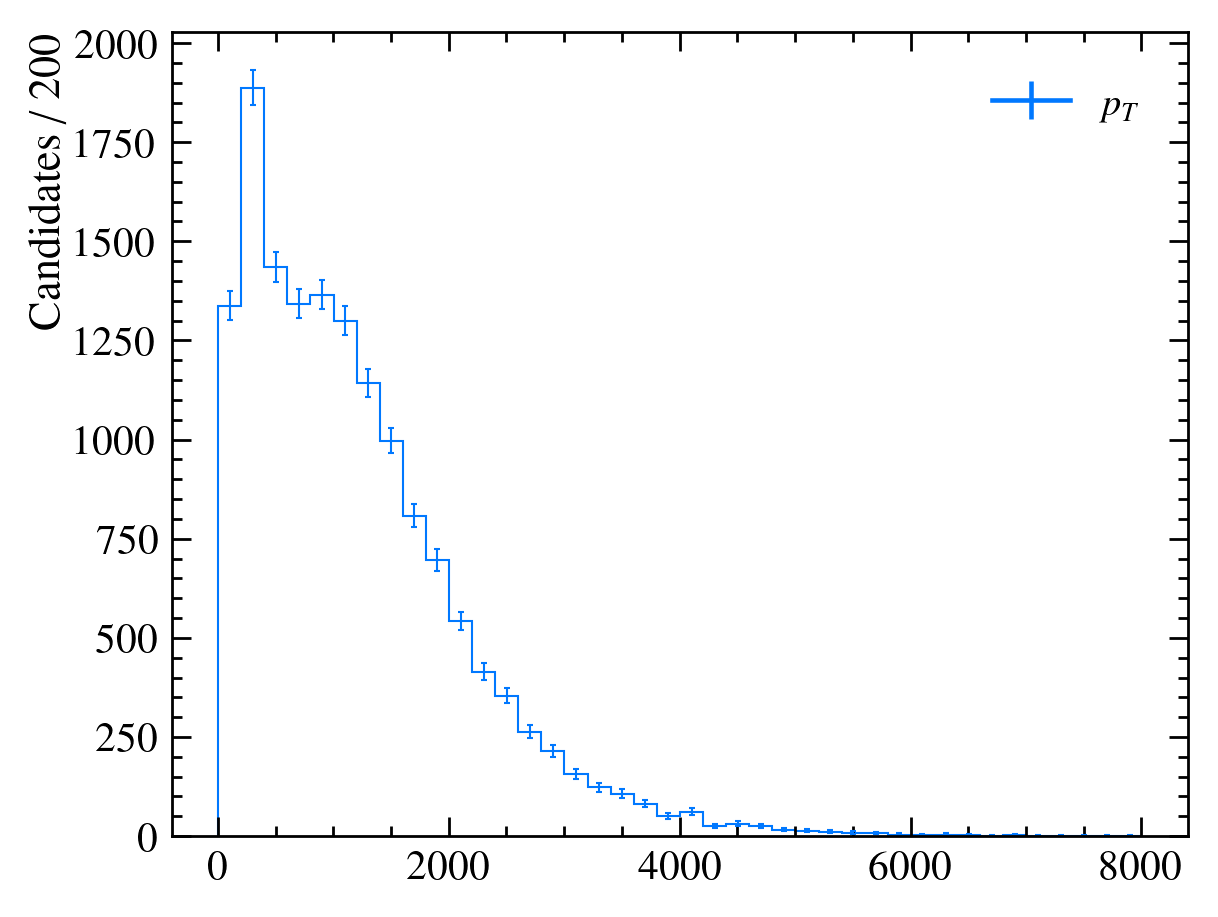

In [11]:

fig, ax = histogram_fig(
    [
        first := HistogramPlot(
            df["Bplus_PT"],
            r"$p_T$",
            bins=200,
            error=True,
            # alpha=0.5,
            linewidth=1.5,
        ),
    ],
    False,
    # preset="Bplus Mass",
    # ylim=[0, 21],
)